# 🎯 Least Squares and Projections — the Best Answer When None Is Exact

**Linear Algebra and Analytic Geometry** · TSIW, ESMAD — Polytechnic of Porto
Lesson notebook **04 of 08** · Library: [`linalg_utils`](../packages/python/src/linalg_utils)

> **Assignment alignment** — supplemental notebook (least squares is not a graded
> assignment), building directly on the projections of notebook 01 and the systems of
> notebook 03.

---

Notebook 03 ended with systems that have a unique solution. But the most common situation in
practice is the opposite: **more equations than unknowns and no exact solution at all** —
think 40 noisy measurements constraining 2 parameters. Least squares answers:

> If $A\mathbf{x} = \mathbf{b}$ cannot be solved, find the $\hat{\mathbf{x}}$ that makes
> $\lVert A\mathbf{x} - \mathbf{b}\rVert$ **as small as possible**.

The key insight is *geometric*: the best $A\hat{\mathbf{x}}$ is the **orthogonal projection**
of $\mathbf{b}$ onto the column space of $A$ — the shadow construction from notebook 01,
promoted from a line to a whole subspace.

## Table of contents

1. [Setup](#setup)
2. [Why exact solutions fail: tall systems](#tall)
3. [Projection onto a column space (2-D)](#proj2d)
4. [Projection onto a plane in ℝ³](#proj3d)
5. [Fitting a line to noisy data](#linefit)
6. [Two algorithms: normal equations vs QR](#algorithms)
7. [Stability face-off](#stability)
8. [Key takeaways](#takeaways)

<a id="setup"></a>
## 1 · Setup

In [1]:
# ── Setup: imports, course library, and a consistent figure style ──────────
import sys
from pathlib import Path

# Make the course library importable straight from a repo clone
# (equivalent to `poetry install` inside packages/python).
_SRC = (Path.cwd().parent / "packages" / "python" / "src").resolve()
if _SRC.exists() and str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import matplotlib.pyplot as plt

# Colorblind-safe categorical palette, used in fixed order across the series.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor":   BASE,
    "axes.labelcolor":  INK,
    "axes.titlecolor":  INK,
    "axes.titleweight": "bold",
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.8,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.prop_cycle":  plt.cycler(color=PALETTE),
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.frameon":   False,
    "figure.dpi":       110,
})
np.set_printoptions(precision=4, suppress=True)

import linalg_utils
print("NumPy", np.__version__, "| linalg_utils loaded from", Path(linalg_utils.__file__).parent)

NumPy 2.3.5 | linalg_utils loaded from C:\Users\diogo\work_code\linear-algebra-with-python\packages\python\src\linalg_utils


<a id="tall"></a>
## 2 · Why exact solutions fail: tall systems

A "tall" system has $m > n$: more equations than unknowns. Generically, $\mathbf{b}$ then
lies **outside the column space** of $A$ (an $n$-dimensional subspace of $\mathbb{R}^m$),
so no exact solution exists — the system is *SI* in notebook 03's language. The least-squares
program replaces "solve exactly" with **minimize the residual**:

$$\hat{\mathbf{x}} \;=\; \arg\min_{\mathbf{x}} \; \lVert A\mathbf{x} - \mathbf{b}\rVert_2^2 .$$

The minimizer is characterized by the **normal equations**
$A^{\mathsf T} A \hat{\mathbf{x}} = A^{\mathsf T}\mathbf{b}$ — which say exactly that the
residual $\mathbf{b} - A\hat{\mathbf{x}}$ is **orthogonal to every column of $A$**.

In [2]:
from linalg_utils.systems import classificar_sistema
from linalg_utils.least_squares import least_squares_qr, least_squares_normal_eq

# 3 equations, 2 unknowns, inconsistent by construction:
A_tall = np.array([[1.0, 0.0],
                   [0.0, 1.0],
                   [1.0, 1.0]])
b_tall = np.array([1.0, 1.0, 0.0])     # third equation contradicts the first two

print("classification:", classificar_sistema(A_tall, b_tall), "(SI = no exact solution)")

ls = least_squares_qr(A_tall, b_tall)
print(f"least-squares x̂        = {ls.x}")
print(f"minimal residual norm  = {ls.residual_norm:.4f}  (cannot be driven to 0)")
print(f"orthogonality check  Aᵀr = {A_tall.T @ ls.residual}   (≈ 0 ⇒ optimal)")

classification: SI (SI = no exact solution)
least-squares x̂        = [0.3333 0.3333]
minimal residual norm  = 1.1547  (cannot be driven to 0)
orthogonality check  Aᵀr = [-0.  0.]   (≈ 0 ⇒ optimal)


<a id="proj2d"></a>
## 3 · Projection onto a column space (2-D)

To *see* the mechanism, we start in the plane: project a target $\mathbf{b}$ onto the span of
the columns of a 2×2 matrix. The fitted point $A\hat{\mathbf{x}}$ is the point of the column
space **closest** to $\mathbf{b}$; the dashed residual meets the space at a right angle.

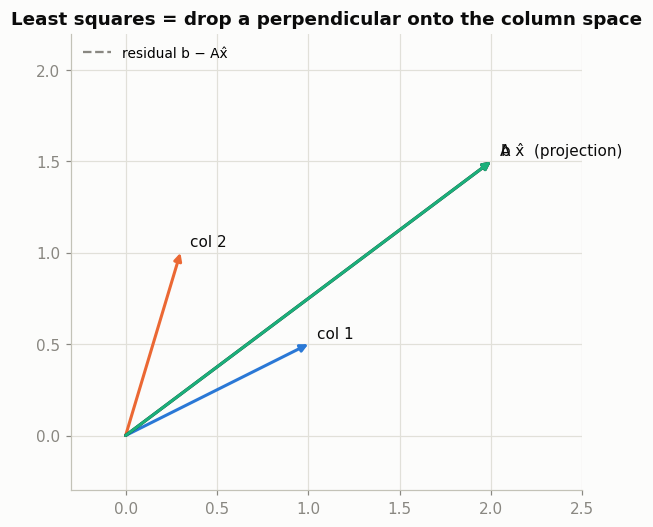

x̂ = [1.8235 0.5882]  → the combination 1.824·col₁ + 0.588·col₂ lands closest to b


In [3]:
A2 = np.array([[1.0, 0.3],
               [0.5, 1.0]])
b2 = np.array([2.0, 1.5])
fit = least_squares_qr(A2, b2)
p2 = A2 @ fit.x                      # projection of b onto span(columns)


def draw_vector(ax, vec, *, color, label, ls="-"):
    ax.annotate("", xy=tuple(vec), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2,
                                linestyle=ls, shrinkA=0, shrinkB=0))
    ax.annotate(label, xy=tuple(vec), xytext=(6, 4),
                textcoords="offset points", color=INK, fontsize=10)


fig, ax = plt.subplots(figsize=(6, 5.4))
draw_vector(ax, A2[:, 0], color=PALETTE[0], label="col 1")
draw_vector(ax, A2[:, 1], color=PALETTE[1], label="col 2")
draw_vector(ax, b2, color=INK, label="b")
draw_vector(ax, p2, color=PALETTE[2], label="A x̂  (projection)")
ax.plot([b2[0], p2[0]], [b2[1], p2[1]], ls="--", color=MUTED, lw=1.5,
        label="residual b − Ax̂")
ax.set_xlim(-0.3, 2.5)
ax.set_ylim(-0.3, 2.2)
ax.set_aspect("equal")
ax.set_title("Least squares = drop a perpendicular onto the column space")
ax.legend(loc="upper left", fontsize=9)
plt.show()

print(f"x̂ = {fit.x}  → the combination {fit.x[0]:.3f}·col₁ + {fit.x[1]:.3f}·col₂ lands closest to b")

<a id="proj3d"></a>
## 4 · Projection onto a plane in ℝ³

The picture generalizes unchanged: in $\mathbb{R}^3$ the columns of a 3×2 matrix span a
**plane**, and the least-squares fit is the foot of the perpendicular dropped from
$\mathbf{b}$ onto that plane. This is precisely the geometry hiding inside every regression.

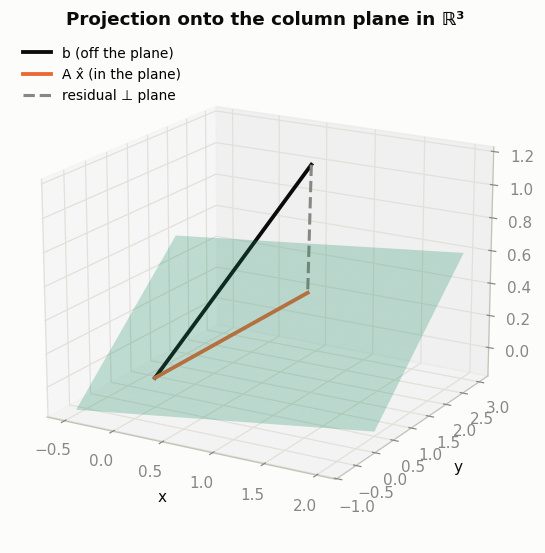

residual · col₁ = +0.00e+00
residual · col₂ = +2.50e-16   (both ≈ 0 ⇒ perpendicular)


In [4]:
plane = np.array([[1.0, 0.0],
                  [0.5, 1.0],
                  [0.0, 0.3]])
target = np.array([1.0, 1.5, 1.2])
fit3 = least_squares_qr(plane, target)
proj3 = plane @ fit3.x

# sample the plane spanned by the two columns
uu, vv = np.meshgrid(np.linspace(-0.5, 2.0, 12), np.linspace(-0.5, 2.0, 12))
pts = plane[:, 0][:, None, None] * uu + plane[:, 1][:, None, None] * vv

fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(pts[0], pts[1], pts[2], alpha=0.25, color=PALETTE[2],
                edgecolor="none")
ax.plot([0, target[0]], [0, target[1]], [0, target[2]],
        color=INK, lw=2.5, label="b (off the plane)")
ax.plot([0, proj3[0]], [0, proj3[1]], [0, proj3[2]],
        color=PALETTE[1], lw=2.5, label="A x̂ (in the plane)")
ax.plot([target[0], proj3[0]], [target[1], proj3[1]], [target[2], proj3[2]],
        ls="--", color=MUTED, lw=2, label="residual ⊥ plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Projection onto the column plane in ℝ³")
ax.legend(loc="upper left", fontsize=9)
ax.view_init(elev=18, azim=-60)
plt.show()

print(f"residual · col₁ = {plane[:, 0] @ fit3.residual:+.2e}")
print(f"residual · col₂ = {plane[:, 1] @ fit3.residual:+.2e}   (both ≈ 0 ⇒ perpendicular)")

<a id="linefit"></a>
## 5 · Fitting a line to noisy data

The workhorse application. To fit $y \approx c_0 + c_1 x$ through noisy points, stack each
observation as a row of the **design matrix**:

$$\underbrace{\begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_m \end{pmatrix}}_{A\;(m \times 2)}
\binom{c_0}{c_1} \approx
\underbrace{\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_m \end{pmatrix}}_{\mathbf{b}}$$

40 equations, 2 unknowns — hopeless exactly, perfect for least squares. Ground truth:
$y = 1 + 2x$ plus Gaussian noise.

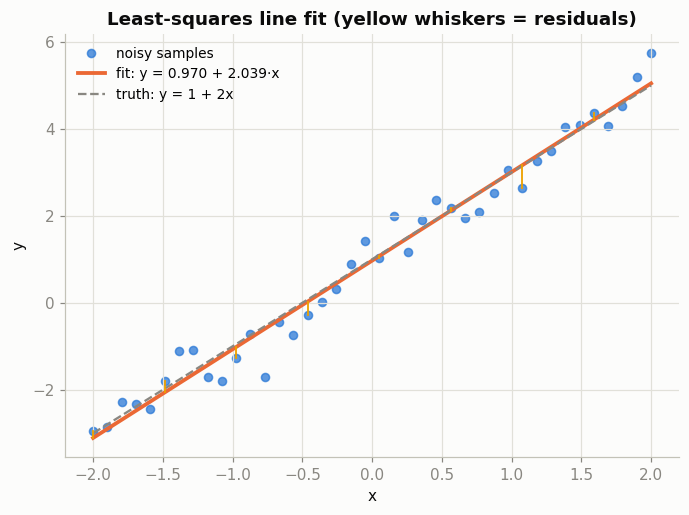

estimated (c₀, c₁) = (0.9698, 2.0387)   vs truth (1, 2)
residual norm      = 2.4722


In [5]:
rng = np.random.default_rng(0)
x_data = np.linspace(-2.0, 2.0, 40)
y_data = 1.0 + 2.0 * x_data + rng.normal(scale=0.5, size=x_data.shape)

A_design = np.column_stack([np.ones_like(x_data), x_data])
fit_line = least_squares_qr(A_design, y_data)
c0, c1 = fit_line.x
y_hat = A_design @ fit_line.x

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.scatter(x_data, y_data, s=28, alpha=0.75, color=PALETTE[0], label="noisy samples")
ax.plot(x_data, y_hat, color=PALETTE[1], lw=2.5,
        label=f"fit: y = {c0:.3f} + {c1:.3f}·x")
ax.plot(x_data, 1 + 2 * x_data, color=MUTED, ls="--", lw=1.5,
        label="truth: y = 1 + 2x")
# a few residual whiskers make 'minimize the residual' concrete
for i in range(0, len(x_data), 5):
    ax.plot([x_data[i], x_data[i]], [y_data[i], y_hat[i]], color=PALETTE[3], lw=1.2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Least-squares line fit (yellow whiskers = residuals)")
ax.legend(fontsize=9)
plt.show()

print(f"estimated (c₀, c₁) = ({c0:.4f}, {c1:.4f})   vs truth (1, 2)")
print(f"residual norm      = {fit_line.residual_norm:.4f}")

<a id="algorithms"></a>
## 6 · Two algorithms: normal equations vs QR

The library implements both classical routes to $\hat{\mathbf{x}}$:

| method | recipe | cost | caveat |
|---|---|---|---|
| **normal equations** | solve $A^{\mathsf T}A\,\hat{\mathbf{x}} = A^{\mathsf T}\mathbf{b}$ | cheapest | condition number gets **squared**: $\kappa(A^{\mathsf T}A) = \kappa(A)^2$ |
| **QR** | factor $A = QR$, solve $R\hat{\mathbf{x}} = Q^{\mathsf T}\mathbf{b}$ | slightly more | works at $\kappa(A)$ — the numerically safe default |

On our well-behaved line-fit problem the two agree to machine precision:

In [6]:
fit_ne = least_squares_normal_eq(A_design, y_data)
fit_qr = least_squares_qr(A_design, y_data)

print(f"normal equations ({fit_ne.method}):  x̂ = {fit_ne.x}")
print(f"QR               ({fit_qr.method}):         x̂ = {fit_qr.x}")
print(f"difference: {np.linalg.norm(fit_ne.x - fit_qr.x):.2e}  — identical here, but keep reading")

normal equations (normal_eq):  x̂ = [0.9698 2.0387]
QR               (qr):         x̂ = [0.9698 2.0387]
difference: 5.55e-16  — identical here, but keep reading


<a id="stability"></a>
## 7 · Stability face-off

To expose the difference we need an **ill-conditioned design matrix**. A Vandermonde matrix
of a degree-7 polynomial on a narrow interval does nicely ($\kappa(A) \sim 10^6$, so
$\kappa(A)^2 \sim 10^{12}$ for the normal equations). We fit both ways at several noise
levels and measure the error against the known true coefficients.

κ(A)  = 1.81e+08
κ(AᵀA) = 3.74e+16   (the square, as advertised)



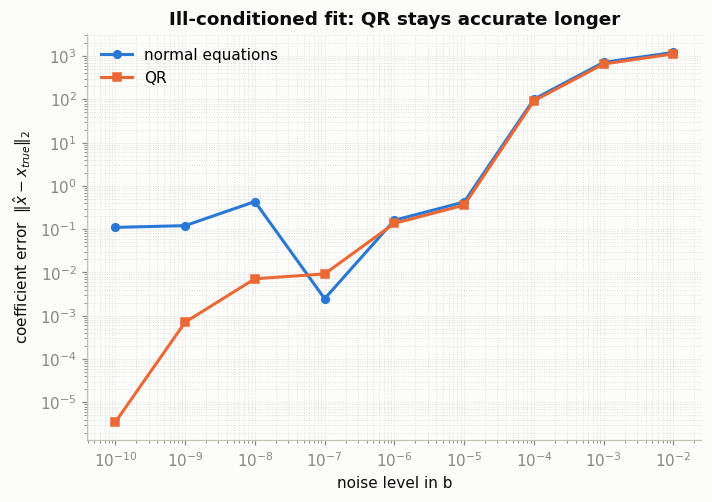

At the lowest noise levels the normal equations are already limited by κ²,
while QR keeps tracking the noise floor — same answer, very different reliability.


In [7]:
rng = np.random.default_rng(42)
degree = 7
xs = np.linspace(1.0, 2.0, 60)                       # narrow interval → correlated powers
A_vand = np.vander(xs, degree + 1, increasing=True)   # columns 1, x, x², …, x⁷
coef_true = rng.normal(size=degree + 1)
b_clean = A_vand @ coef_true

print(f"κ(A)  = {np.linalg.cond(A_vand):.2e}")
print(f"κ(AᵀA) = {np.linalg.cond(A_vand.T @ A_vand):.2e}   (the square, as advertised)\n")

noise_levels = np.geomspace(1e-10, 1e-2, 9)
err_ne, err_qr = [], []
for eps in noise_levels:
    noisy = b_clean + rng.normal(scale=eps, size=b_clean.shape)
    err_ne.append(np.linalg.norm(least_squares_normal_eq(A_vand, noisy).x - coef_true))
    err_qr.append(np.linalg.norm(least_squares_qr(A_vand, noisy).x - coef_true))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.loglog(noise_levels, err_ne, marker="o", ms=5, lw=2, color=PALETTE[0],
          label="normal equations")
ax.loglog(noise_levels, err_qr, marker="s", ms=5, lw=2, color=PALETTE[1], label="QR")
ax.set_xlabel("noise level in b")
ax.set_ylabel(r"coefficient error  $\|\hat{x} - x_{true}\|_2$")
ax.set_title("Ill-conditioned fit: QR stays accurate longer")
ax.grid(True, which="both", ls=":", lw=0.6)
ax.legend()
plt.show()

print("At the lowest noise levels the normal equations are already limited by κ²,")
print("while QR keeps tracking the noise floor — same answer, very different reliability.")

<a id="takeaways"></a>
## 8 · Key takeaways

- When $A\mathbf{x}=\mathbf{b}$ has no solution, least squares finds the $\hat{\mathbf{x}}$
  minimizing $\lVert A\mathbf{x}-\mathbf{b}\rVert$ — and $A\hat{\mathbf{x}}$ is the
  **orthogonal projection** of $\mathbf{b}$ onto the column space.
- Optimality has a fingerprint: the residual is **orthogonal to every column**
  ($A^{\mathsf T}\mathbf{r} = \mathbf{0}$) — cheap to verify, always worth checking.
- **Regression is projection**: the design-matrix trick turns any curve-fitting problem into
  $A\hat{\mathbf{x}} \approx \mathbf{b}$.
- Prefer **QR** over the normal equations when conditioning is in doubt: forming
  $A^{\mathsf T}A$ squares the condition number, QR does not.

**Next:** [05 — QR and SVD](05_qr_and_svd.ipynb): the factorization we just used as a tool
becomes the object of study, together with the SVD.